## 1. The Lognormal Distribution

### Derivation of the Mode
The mode is the point where the probability density function (PDF) $f_X(x)$ reaches its maximum. For a lognormal variable $X \sim \text{LogN}(\mu, \sigma^2)$, the PDF for $x > 0$ is:
$$f_X(x) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right)$$

To find the maximum, we take the derivative of the log-density (which is easier and shares the same maximum) with respect to $x$ and set it to zero:
**Log-density** = $\ln(f_X(x)) = -\ln(x) - \ln(\sigma\sqrt{2\pi}) - \frac{(\ln x - \mu)^2}{2\sigma^2}$

$\frac{d}{dx} \ln(f_X(x)) = -\frac{1}{x} - \frac{2(\ln x - \mu)}{2\sigma^2} \cdot \frac{1}{x} = 0$

$-\frac{1}{x} \left[ 1 + \frac{\ln x - \mu}{\sigma^2} \right] = 0$

$1 + \frac{\ln x - \mu}{\sigma^2} = 0 \implies \ln x - \mu = -\sigma^2 \implies \ln x = \mu - \sigma^2$

$\text{Mod}\{X\} = e^{\mu - \sigma^2}$

---

### Visualization ($\mu = 0, \sigma = 1$)


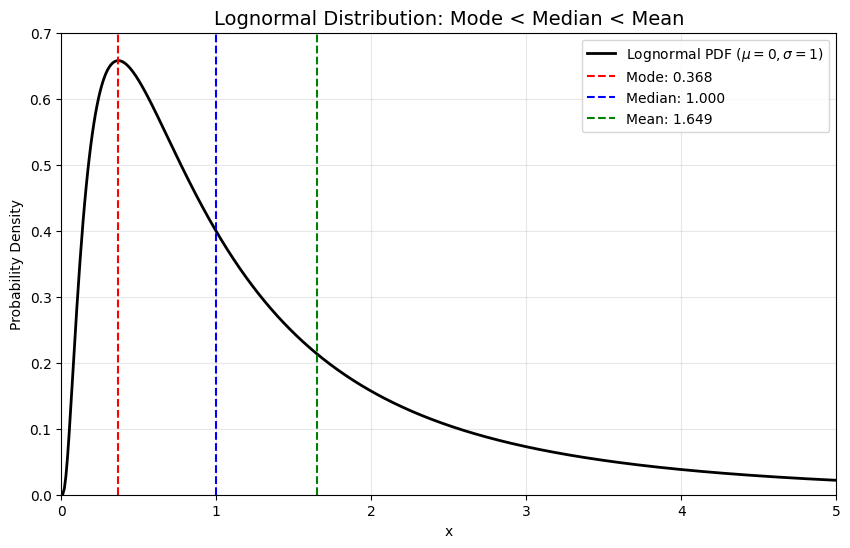

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Parameters
mu = 0
sigma = 1

# Calculate statistics
mode = np.exp(mu - sigma**2)
median = np.exp(mu)
mean = np.exp(mu + (sigma**2) / 2)

# Generate distribution data
x = np.linspace(0, 5, 500)
pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, 'k-', lw=2, label=f'Lognormal PDF ($\mu={mu}, \sigma={sigma}$)')

# Add vertical lines for mean, median, and mode
plt.axvline(mode, color='red', linestyle='--', label=f'Mode: {mode:.3f}')
plt.axvline(median, color='blue', linestyle='--', label=f'Median: {median:.3f}')
plt.axvline(mean, color='green', linestyle='--', label=f'Mean: {mean:.3f}')

# Formatting
plt.title('Lognormal Distribution: Mode < Median < Mean', fontsize=14)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 0.7)

plt.show()

## 2. Elicitability of the Quantile
A functional is elicitable if it minimizes the expected value of a loss function. For a confidence level $c$, the quantile $q_c$ is elicitable because it is the solution to the minimization of the **Pinball Loss** function:

$$\ell(x, q) = (x - q)^+ + \frac{1-c}{c}(x - q)^-$$

Where $(z)^+$ is the positive part and $(z)^-$ is the negative part. 

**proof**:
The maximum expectation has:
$$\frac{d}{dq} \int_{-\infty}^{\infty} \ell(x, q) f_X(x) dx = 0$$

$$\frac{d}{dq} [ \int_{-\infty}^{q} \frac{1-c}{c}(q-x) f_X(x) \, dx + \int_{q}^{\infty} (x-q) f_X(x) \, dx]=0$$

$$\frac{1-c}{c} \int_{-\infty}^{q} f_X(x) \, dx - \int_{q}^{\infty} f_X(x) \, dx = 0$$

$$\frac{1-c}{c} F_X(q) - (1 - F_X(q)) = 0$$

$$(1-c) F_X(q) - c(1 - F_X(q)) = 0$$

$$F_X(q) - c F_X(q) - c + c F_X(q) = 0$$

$$F_X(q) - c = 0$$

$$F_X(q) = c => q = F_X^{-1}(c)$$
---

## 3. The Markov Property

**Proof:**
By the definition of conditional probability:

$$f(x \mid z, y) = \frac{f(x, y, z)}{f(y, z)}$$

and we have:

$$f(x, y, z) = f(x, y \mid z) f(z)$$

Since $X$ and $Y$ are conditionally independent given $Z$ ($X \perp Y \mid Z$), 

$$f(x, y \mid z) = f(x \mid z) f(y \mid z)$$

Substitute this back into the equation from step 1:
    
$$f(x \mid z, y) = \frac{f(x \mid z) f(y \mid z) f(z)}{f(y, z)}$$

$$f(x \mid z, y) = \frac{f(x \mid z) f(y, z)}{f(y, z)}$$

$$f(x \mid z, y) = f(x \mid z)$$


## 4. Mathematical Proofs: Copulas

1. Probability Integral Transform
$$F_U(u) = \mathbb{P}\{U \le u\}$$

Substitute the definition of $U$:

$$F_U(u) = \mathbb{P}\{F_X(X) \le u\}$$

Assuming $F_X$ is strictly increasing, we can apply the inverse function $F_X^{-1}$:

$$F_U(u) = \mathbb{P}\{X \le F_X^{-1}(u)\}$$

$$F_U(u) = u$$

$$U = F_X(X) \sim \text{Unif}([0, 1])$$

2. Copula Density Relationship

Sklar's Theorem:

$$F_{\mathbf{X}}(x_1, \dots, x_n) = C(F_{X_1}(x_1), \dots, F_{X_n}(x_n))$$

$$\frac{\partial^n}{\partial x_1 \dots \partial x_n} F_{\mathbf{X}}(x_1, \dots, x_n) = f_{\mathbf{X}}(x_1, \dots, x_n)$$

$$=\frac{\partial^n}{\partial x_1 \dots \partial x_n} C(u_1, \dots, u_n) = \frac{\partial^n C(u_1, \dots, u_n)}{\partial u_1 \dots \partial u_n} \cdot \prod_{i=1}^{n} f_{X_i}(x_i)$$

Define copula density as
$$c(u_1, \dots, u_n) = \frac{\partial^n C(u_1, \dots, u_n)}{\partial u_1 \dots \partial u_n}$$

By substitution we get

$$f_{\mathbf{X}}(x_1, \dots, x_n) = c(u_1, \dots, u_n) \cdot \prod_{i=1}^{n} f_{X_i}(x_i)$$

$$c(u_1, \dots, u_n) = \frac{f_{\mathbf{X}}(q_{X_1}(u_1), \dots, q_{X_n}(u_n))}{\prod_{i=1}^{n} f_{X_i}(q_{X_i}(u_i))}$$

## 5. Python Simulations of Copulas:

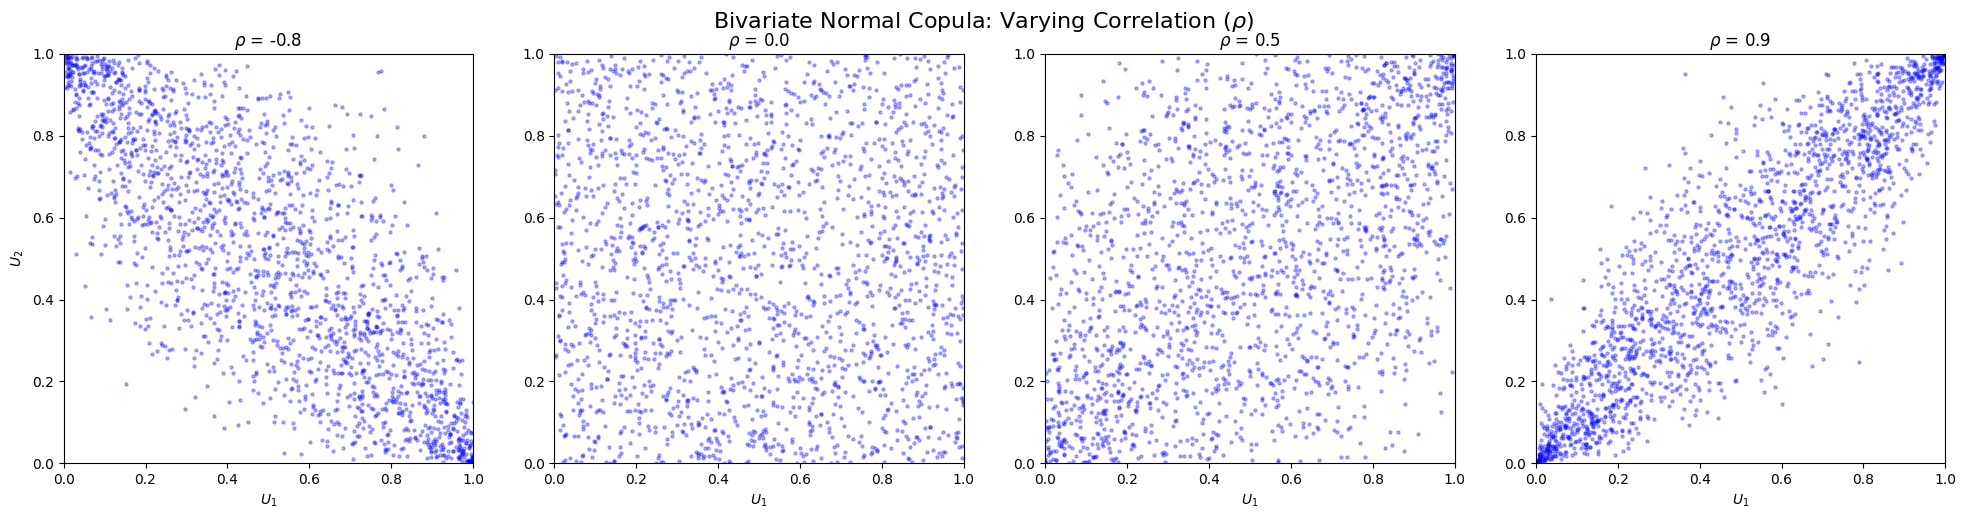

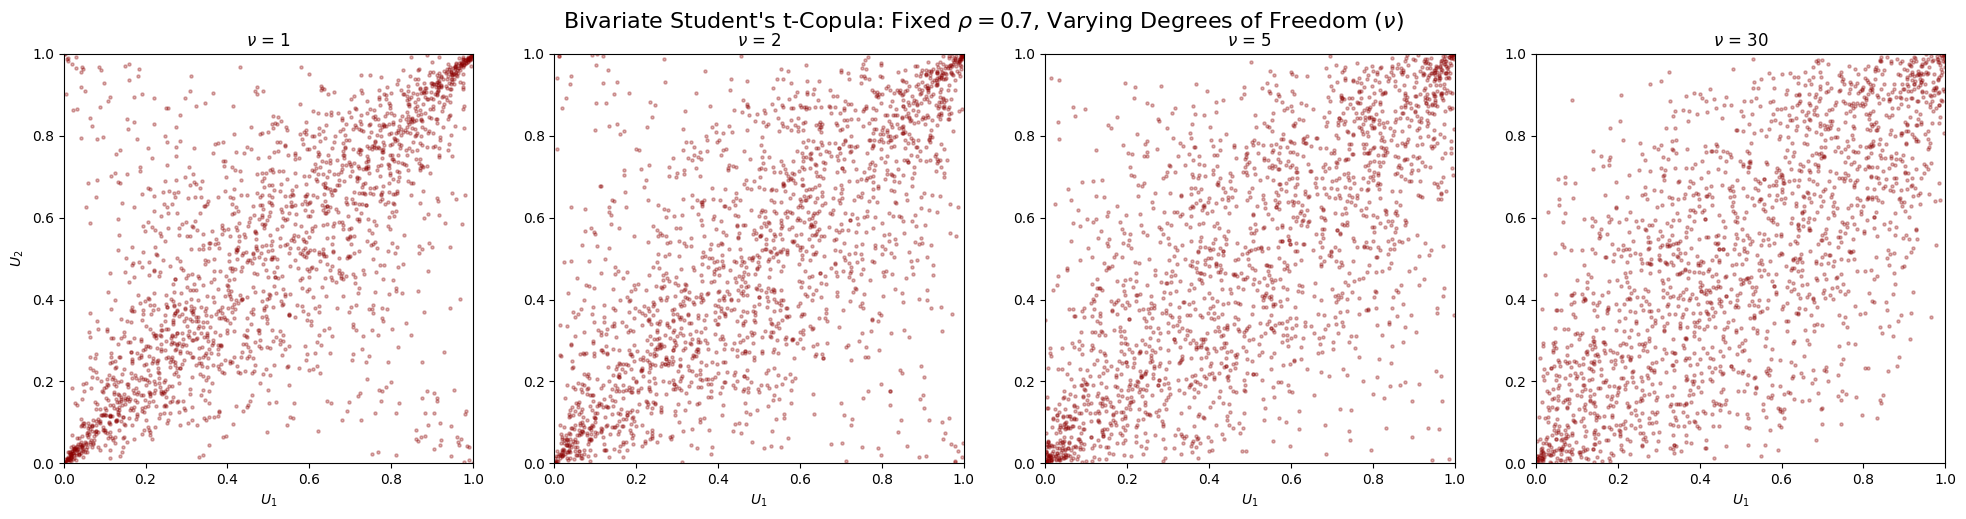

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Set seed for reproducibility
np.random.seed(42)
n_samples = 2000


# 1. Bivariate Normal Copula Function
def simulate_normal_copula(rho, n):
    """Generates samples from a Bivariate Normal Copula."""
    # covariance matrix
    cov_matrix = np.array([[1.0, rho], 
                           [rho, 1.0]])
    
    # 1. Draw from multivariate normal
    Z = np.random.multivariate_normal(mean=[0, 0], cov=cov_matrix, size=n)
    
    # 2. Apply the normal CDF to get uniform marginals (Probability Integral Transform)
    U = norm.cdf(Z)
    return U[:, 0], U[:, 1]

# 2. Bivariate Student's t-Copula Function
def simulate_t_copula(rho, nu, n):
    """Generates samples from a Bivariate Student's t-Copula."""
    cov_matrix = np.array([[1.0, rho], 
                           [rho, 1.0]])
    
    # 1. Draw from multivariate normal
    Z = np.random.multivariate_normal(mean=[0, 0], cov=cov_matrix, size=n)
    
    # 2. Draw from Chi-squared distribution for the denominator
    S = np.random.chisquare(df=nu, size=n)
    
    # 3. Construct the multivariate t-distribution
    # T = Z * sqrt(nu / S)
    T = Z * np.sqrt(nu / S)[:, np.newaxis]
    
    # 4. Apply the univariate t-CDF to get uniform marginals
    U = t.cdf(T, df=nu)
    return U[:, 0], U[:, 1]

## Visualizatio
# Setup figure for Normal Copula comparison
rhos_to_test = [-0.8, 0.0, 0.5, 0.9]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Bivariate Normal Copula: Varying Correlation ($\\rho$)', fontsize=16)

for i, rho in enumerate(rhos_to_test):
    u1, u2 = simulate_normal_copula(rho, n_samples)
    axes[i].scatter(u1, u2, alpha=0.3, s=5, color='blue')
    axes[i].set_title(f'$\\rho$ = {rho}')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_aspect('equal')
    axes[i].set_xlabel('$U_1$')
    if i == 0: axes[i].set_ylabel('$U_2$')

plt.tight_layout()
plt.show()

# Setup figure for Student's t-Copula comparison
# Fixing rho=0.7 and varying degrees of freedom (nu) to show tail dependence
nus_to_test = [1, 2, 5, 30]
fixed_rho = 0.7

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
fig2.suptitle(f"Bivariate Student's t-Copula: Fixed $\\rho={fixed_rho}$, Varying Degrees of Freedom ($\\nu$)", fontsize=16)

for i, nu in enumerate(nus_to_test):
    u1, u2 = simulate_t_copula(fixed_rho, nu, n_samples)
    axes2[i].scatter(u1, u2, alpha=0.3, s=5, color='darkred')
    axes2[i].set_title(f'$\\nu$ = {nu}')
    axes2[i].set_xlim(0, 1)
    axes2[i].set_ylim(0, 1)
    axes2[i].set_aspect('equal')
    axes2[i].set_xlabel('$U_1$')
    if i == 0: axes2[i].set_ylabel('$U_2$')

plt.tight_layout()
plt.show()

## 6. Stock Returns Analysis

--- Mean Vector ---
μ = [0.175 0.133]

--- Covariance Matrix ---
Σ = 
[[ 0.179776 -0.081225]
 [-0.081225  0.120409]]

--- Multivariate Z-Score ---
Realized Return x = [0.1 0.1]
||z_X(x)|| = 0.291

--- Spectral Decomposition ---
Eigenvalues (λ): [0.23657146 0.06361354]
Eigenvectors (E): 
[[-0.81952588 -0.57304217]
 [ 0.57304217 -0.81952588]]



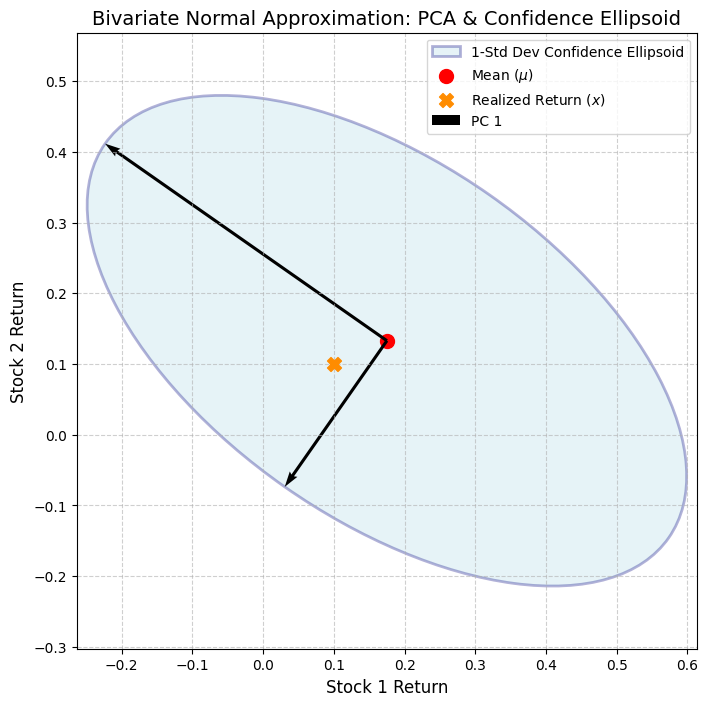

--- Portfolio Statistics ---
Weights w = [0.2 0.8]
Expected Return: 0.1414 (14.14%)
Variance: 0.058261
Volatility (Std Dev): 0.2414 (24.14%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


## 1. Mean, Covariance, and Z-scores
# Defining the Mean Vector
mu = np.array([0.175, 0.133])

# Defining the Covariance Matrix based on the provided volatilities
cov_matrix = np.array([
    [0.424**2, -(0.285**2)],
    [-(0.285**2), 0.347**2]
])

print("--- Mean Vector ---")
print(f"μ = {mu}\n")

print("--- Covariance Matrix ---")
print(f"Σ = \n{cov_matrix}\n")

# Calculating the Multivariate Absolute Z-score for realization x = [10%, 10%]'
x_realized = np.array([0.10, 0.10])
inv_cov = np.linalg.inv(cov_matrix)
diff = x_realized - mu

# Mahalanobis Distance formulation: sqrt((x - μ)' * Σ^-1 * (x - μ))
z_score_sq = diff.T @ inv_cov @ diff
z_score = np.sqrt(z_score_sq)

print("--- Multivariate Z-Score ---")
print(f"Realized Return x = {x_realized}")
print(f"||z_X(x)|| = {z_score:.3f}\n")


#＃ 2. Spectral Decomposition (PCA) & Ellipsoid
# Perform eigendecomposition of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("--- Spectral Decomposition ---")
print(f"Eigenvalues (λ): {eigenvalues}")
print(f"Eigenvectors (E): \n{eigenvectors}\n")

# Visualization: Confidence Ellipsoid
# Calculate the angle of the ellipse based on the primary eigenvector
angle_rad = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
angle_deg = np.degrees(angle_rad)

# The width and height of the 1-Standard-Deviation ellipse are 2 * sqrt(eigenvalue)
width = 2 * np.sqrt(eigenvalues[0])
height = 2 * np.sqrt(eigenvalues[1])

fig, ax = plt.subplots(figsize=(8, 8))

# Draw the Confidence Ellipse
ell = Ellipse(xy=mu, width=width, height=height, angle=angle_deg, 
              edgecolor='navy', fc='lightblue', alpha=0.3, lw=2, 
              label='1-Std Dev Confidence Ellipsoid')
ax.add_patch(ell)

# Plot the center (Mean) and the Realized Return
ax.scatter(*mu, color='red', s=100, label='Mean ($\mu$)')
ax.scatter(*x_realized, color='darkorange', marker='X', s=100, zorder=5, label='Realized Return ($x$)')

# Plot the Principal Components (Eigenvectors scaled by sqrt of Eigenvalues)
for i in range(2):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i])
    ax.quiver(*mu, *vec, angles='xy', scale_units='xy', scale=1, 
              color='black', width=0.005, 
              label=f'PC {i+1}' if i == 0 else "")

ax.autoscale()
ax.set_aspect('equal', 'datalim')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title('Bivariate Normal Approximation: PCA & Confidence Ellipsoid', fontsize=14)
ax.set_xlabel('Stock 1 Return', fontsize=12)
ax.set_ylabel('Stock 2 Return', fontsize=12)
ax.legend()

plt.show()

## 3. Portfolio Mean and Variance
# Portfolio weights w = [0.2, 0.8]^T
w = np.array([0.2, 0.8])

# Expected Portfolio Return: w^T * μ
port_mean = w.T @ mu

# Portfolio Variance: w^T * Σ * w
port_variance = w.T @ cov_matrix @ w
port_volatility = np.sqrt(port_variance)

print("--- Portfolio Statistics ---")
print(f"Weights w = {w}")
print(f"Expected Return: {port_mean:.4f} ({port_mean*100:.2f}%)")
print(f"Variance: {port_variance:.6f}")
print(f"Volatility (Std Dev): {port_volatility:.4f} ({port_volatility*100:.2f}%)")



To set the stage for these derivations, recall the definition of the linear projection (or linear conditional expectation) of $X$ onto $Z$:
$$\mathbb{E}\{X \parallel Z\} \equiv \mathbb{E}\{X\} + \text{Cv}\{X, Z\}\text{Cv}\{Z\}^{-1}(Z - \mathbb{E}\{Z\})$$



### 1. Affine Invariance

**Proof:**
Mean-covariance independence ($X \perp_{mc} Z$) indicates zero covariance:

$$\text{Cv}\{X, Z\} = 0$$

Let $\tilde{X} = a_X + b_X X$ and $\tilde{Z} = a_Z + b_Z Z$

$$\text{Cv}\{a_X + b_X X, a_Z + b_Z Z\} = \text{Cv}\{b_X X, b_Z Z\}$$

$$\text{Cv}\{\tilde{X}, \tilde{Z}\} = b_X \text{Cv}\{X, Z\} b_Z^\top = 0$$

$$\Rightarrow\tilde{X} \perp_{mc} \tilde{Z}$$

Reverse arrow:
$$\text{Cv}\{X, Z\} = b_X^\top \text{Cv}\{\tilde{X}, \tilde{Z}\} b_X \times \frac{1}{|b_X|^2} = 0$$
$$\Rightarrow X \perp_{mc} Z$$
if $\text{Cv}\{\tilde{X}, \tilde{Z}\}=0$, i.e. 
$$\tilde{X} \perp_{mc} \tilde{Z}$$

---

### 2. Residual Properties
**Proof 1: ($\mathbb{E}\{\mathring{\varepsilon}\} = 0$)**
$$\mathbb{E}\{X \parallel Z\} \equiv \alpha_{X \parallel Z} + \beta_{X \parallel Z} Z$$
$$\mathbb{E}\{\mathring{\varepsilon}\} = \mathbb{E}\{X - (\alpha_{X \parallel Z} + \beta_{X \parallel Z} Z)\}$$
$$\mathbb{E}\{\mathring{\varepsilon}\} = \mu_X - \alpha_{X \parallel Z} - \beta_{X \parallel Z} \mu_Z$$
$$\mathbb{E}\{\mathring{\varepsilon}\} = \mu_X - (\mu_X - \sigma_{X,Z} (\sigma_Z^2)^{-1} \mu_Z) - \sigma_{X,Z} (\sigma_Z^2)^{-1} \mu_Z = 0$$


**Proof 2: ($\text{Cv}\{\mathring{\varepsilon}, a + bZ\} = 0$)**
$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \text{Cv}\{X - (\alpha_{X \parallel Z} + \beta_{X \parallel Z} Z), Z\}$$
$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \text{Cv}\{X, Z\} - \text{Cv}\{\beta_{X \parallel Z} Z, Z\}$$
$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \sigma_{X,Z} - \beta_{X \parallel Z} \sigma_Z^2$$
$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \sigma_{X,Z} - [\sigma_{X,Z} (\sigma_Z^2)^{-1}] \sigma_Z^2$$
$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \sigma_{X,Z} - \sigma_{X,Z} = 0$$

---

### 3. Total Covariance
**Proof:**
$$\mathbb{E}\{\text{Cv}\{X \parallel Z\}\} + \text{Cv}\{\mathbb{E}\{X \parallel Z\}\}$$
$$=\mathbb{E}\{\sigma_X^2 - \beta_{X \parallel Z} \sigma_Z^2 \beta_{X \parallel Z}^\top\} + \text{Cv}\{\alpha_{X \parallel Z} + \beta_{X \parallel Z} Z \}$$
$$ = \sigma_X^2 - \beta_{X \parallel Z} \sigma_Z^2 \beta_{X \parallel Z}^\top + \beta_{X \parallel Z} \sigma_Z^2 \beta_{X \parallel Z}^\top = \text{Cv}\{X\} $$


---

### 4. Normal Coincidence

**1. Expectation Coincidence:**
$$\mathbb{E}\{\mathring{\varepsilon}\|Z\} = \mathbb{E}\{X - \mathbb{E}\{X||Z\}\|Z\}$$
Since $\text{Cv}\{\mathring{\varepsilon},Z\}=0$:
$$\mathbb{E}\{\mathring{\varepsilon}\} = \mathbb{E}\{X\|Z\} - \mathbb{E}\{X||Z\}$$
$$\mathbb{E}\{X\|Z\} = \mathbb{E}\{X||Z\}$$
$$\mathbb{E}^{N}\{X \parallel Z\} = \mathbb{E}^{N}\{X \mid Z\}$$

---
assume that $X$, $Y$, and $Z$ follow a joint multivariate normal distribution:
$$\begin{bmatrix} X \\ Y \\ Z \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \\ \mu_Z \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} & \Sigma_{XZ} \\ \Sigma_{YX} & \Sigma_{YY} & \Sigma_{YZ} \\ \Sigma_{ZX} & \Sigma_{ZY} & \Sigma_{ZZ} \end{bmatrix} \right)$$


**2. Covariance Coincidence**

We use the residual from the best linear predictor, defined as $\mathring{\varepsilon} = X - \mathbb{E}\{X \parallel Z\}$. 
$$\text{Cv}\{X \parallel Z\}  = \text{Var}(\mathring{\varepsilon}) = \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$$


The residual $\mathring{\varepsilon}$ is uncorrelated with $Z$ ($\text{Cov}(\mathring{\varepsilon}, Z) = 0$).
Because $X$ and $Z$ are jointly normal, any linear combination of them (like $\mathring{\varepsilon}$) is also jointly normal with $Z$. For jointly normal variables, zero covariance implies strict independence:
$$\mathring{\varepsilon} \perp\!\!\!\perp Z$$

$$\text{Cv}\{X \mid Z\} = \text{Var}(X \mid Z) = \text{Var}(\mathbb{E}\{X \parallel Z\} + \mathring{\varepsilon} \mid Z)$$

$$\text{Var}(\mathbb{E}\{X \parallel Z\} + \mathring{\varepsilon} \mid Z) = \text{Var}(\mathring{\varepsilon} \mid Z)$$

$$\text{Var}(\mathring{\varepsilon} \mid Z) = \text{Var}(\mathring{\varepsilon})$$

$$\text{Cv}^N\{X \mid Z\} = \text{Var}(\mathring{\varepsilon}) = \text{Cv}^N\{X \parallel Z\}$$

---

**3. Independence Equivalence**

**Left to Right**
Assume $X \perp\!\!\!\perp Y \mid Z$. 
If two random variables are statistically independent, their covariance is necessarily zero. 
$$\text{If } X \perp\!\!\!\perp Y \mid Z \implies \text{Cv}\{X, Y \mid Z\} = 0$$

**Right to Left**
Assume $X \perp\!\!\!\perp_{mc} Y \mid Z$, which means $\text{Cv}\{X, Y \mid Z\} = 0$.

By the fundamental property of the multivariate normal distribution:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \Bigg| Z=z \sim \mathcal{N} \left( \begin{bmatrix} \mu_{X|z} \\ \mu_{Y|z} \end{bmatrix}, \begin{bmatrix} \text{Cv}\{X \mid Z\} & \text{Cv}\{X, Y \mid Z\} \\ \text{Cv}\{Y, X \mid Z\} & \text{Cv}\{Y \mid Z\} \end{bmatrix} \right)$$

Becuase $\text{Cv}\{X, Y \mid Z\} = 0$, 
$$\Sigma_{(X,Y)|Z} = \begin{bmatrix} \text{Cv}\{X \mid Z\} & 0 \\ 0 & \text{Cv}\{Y \mid Z\} \end{bmatrix}$$


The probability density function (PDF) of a bivariate normal distribution will be:
$$f_{X,Y \mid Z}(x, y \mid z) = f_{X \mid Z}(x \mid z) \cdot f_{Y \mid Z}(y \mid z)$$

Which indicates 
$X \perp\!\!\!\perp Y \mid Z$.

## 8. Projection & Residuals

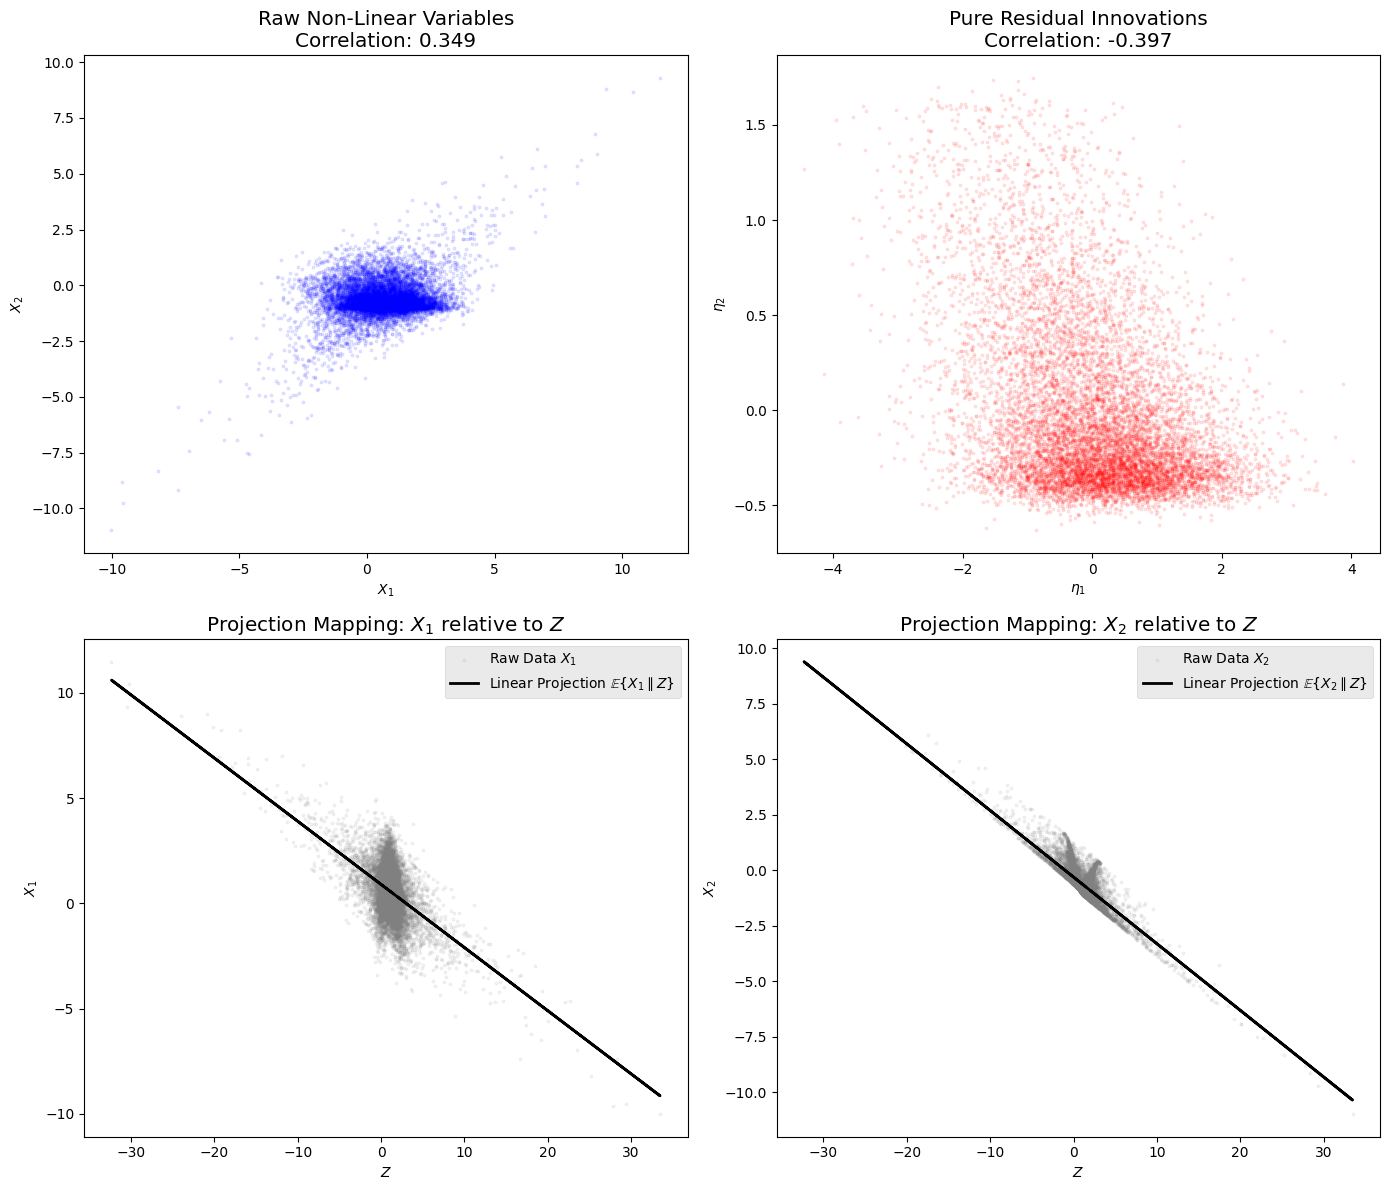

Empirical Correlation (X1, X2): 0.3488
Empirical Partial Correlation (eta1, eta2): -0.3970


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Number of Monte Carlo simulations
N = 10000

# ---------------------------------------------------------
# 1. Generate Independent Base Variables
# ---------------------------------------------------------
# Three perfectly independent normal variables
e1 = np.random.normal(0, 1, N)
e2 = np.random.normal(0, 1, N)
e3 = np.random.normal(0, 1, N)

# ---------------------------------------------------------
# 2. Define Complex Non-Linear Variables
# ---------------------------------------------------------
# Calculate the constant coefficient for X2 and eta2
e_const = ((np.exp(1) - 1)**2) / (6 * np.exp(2))

# Generate dependent derivative vectors X1 and X2
X1 = e1 + 0.2 * e2 + np.cos(e2) + 0.2 * (e3**3)
X2 = 0.2 * e2 + e_const * e3 - np.cos(e2) + 0.2 * (e3**3)

# Generate mutual common anchor parameter Z
Z = 1 - (2/3) * (e2 + e3**3)

# ---------------------------------------------------------
# 3. Compute Projections & Residuals
# ---------------------------------------------------------
# Explicit physical integration parameters
alpha1 = 0.3 + np.exp(-0.5)
alpha2 = 0.3 - np.exp(-0.5)
beta = -0.3

# Calculate linear projections E{X || Z}
E_X1_Z = alpha1 + beta * Z
E_X2_Z = alpha2 + beta * Z

# Calculate the underlying base residual systems (innovations)
# Note: You can also compute these empirically via (X1 - E_X1_Z)
eta1 = e1 + np.cos(e2) - np.exp(-0.5)
eta2 = e_const * e3 - np.cos(e2) + np.exp(-0.5)

# ---------------------------------------------------------
# 4. Generate Visualizations
# ---------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
plt.style.use('ggplot')

# Plot A: Scatter Plot of Non-Linear Setup (X1 vs X2)
axs[0, 0].scatter(X1, X2, alpha=0.1, color='blue', s=5)
axs[0, 0].set_title(f'Raw Non-Linear Variables\nCorrelation: {np.corrcoef(X1, X2)[0,1]:.3f}')
axs[0, 0].set_xlabel('$X_1$')
axs[0, 0].set_ylabel('$X_2$')

# Plot B: Residual Independent Boundaries (eta1 vs eta2)
axs[0, 1].scatter(eta1, eta2, alpha=0.1, color='red', s=5)
axs[0, 1].set_title(f'Pure Residual Innovations\nCorrelation: {np.corrcoef(eta1, eta2)[0,1]:.3f}')
axs[0, 1].set_xlabel('$\eta_1$')
axs[0, 1].set_ylabel('$\eta_2$')

# Plot C: Projection of X1 onto Z
axs[1, 0].scatter(Z, X1, alpha=0.1, color='gray', s=5, label='Raw Data $X_1$')
axs[1, 0].plot(Z, E_X1_Z, color='black', linewidth=2, label='Linear Projection $\mathbb{E}\{X_1 \parallel Z\}$')
axs[1, 0].set_title('Projection Mapping: $X_1$ relative to $Z$')
axs[1, 0].set_xlabel('$Z$')
axs[1, 0].set_ylabel('$X_1$')
axs[1, 0].legend()

# Plot D: Projection of X2 onto Z
axs[1, 1].scatter(Z, X2, alpha=0.1, color='gray', s=5, label='Raw Data $X_2$')
axs[1, 1].plot(Z, E_X2_Z, color='black', linewidth=2, label='Linear Projection $\mathbb{E}\{X_2 \parallel Z\}$')
axs[1, 1].set_title('Projection Mapping: $X_2$ relative to $Z$')
axs[1, 1].set_xlabel('$Z$')
axs[1, 1].set_ylabel('$X_2$')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# Verify the uncorrelation mechanically
print(f"Empirical Correlation (X1, X2): {np.corrcoef(X1, X2)[0,1]:.4f}")
print(f"Empirical Partial Correlation (eta1, eta2): {np.corrcoef(eta1, eta2)[0,1]:.4f}")